In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

In [2]:
# 데이터 불러오기
X = pd.read_csv('./data/credit card.csv')

# 'CUST_ID' 열 삭제
X = X.drop('CUST_ID', axis=1)

# 결측치를 바로 앞의 값으로 채우기
X.fillna(method='ffill', inplace=True)

print(X.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

C:\Users\asus\AppData\Local\Temp\ipykernel_12940\2867883888.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)


In [3]:
# 데이터를 표준화 스케일링합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터를 정규화합니다.
X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized)

In [4]:
# 2개의 주성분으로 차원을 축소합니다.
pca = PCA(n_components=2)
X_principal = pca.fit_transform(X_normalized)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']

In [5]:
# DBSCAN 모델을 생성하고 실행합니다.
db_default = DBSCAN(eps=0.0375, min_samples=3).fit(X_principal)
labels = db_default.labels_

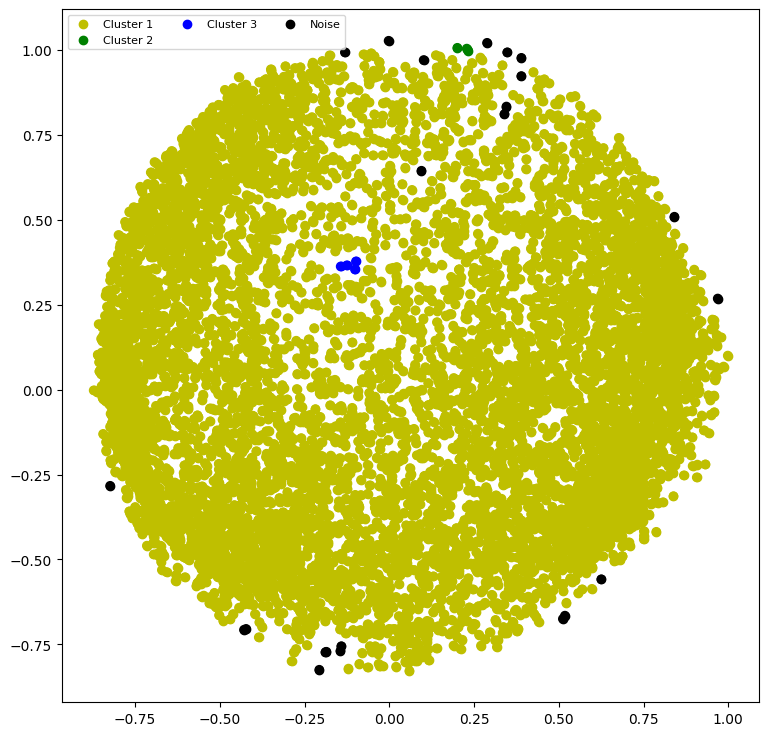

In [6]:
# 클러스터링 결과를 시각화합니다.
colours = {}
colours[0] = 'y'
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'

# 각 데이터 포인트에 대한 색상을 저장할 벡터를 만듭니다.
cvec = [colours[label] for label in labels]

# 플롯을 만듭니다.
plt.figure(figsize=(9, 9))

# 각 데이터 포인트를 플로팅합니다.
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)

# 범례를 추가합니다.
plt.legend((plt.scatter(X_principal['P1'][labels == 0], X_principal['P2'][labels == 0], c='y'),
            plt.scatter(X_principal['P1'][labels == 1], X_principal['P2'][labels == 1], c='g'),
            plt.scatter(X_principal['P1'][labels == 2], X_principal['P2'][labels == 2], c='b'),
            plt.scatter(X_principal['P1'][labels == -1], X_principal['P2'][labels == -1], c='k')),
           ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Noise'],
           scatterpoints=1,
           loc='upper left',
           ncol=3,
           fontsize=8)

plt.show()

In [7]:
# min_samples 값을 10으로 설정하여 DBSCAN 모델을 생성하고 실행합니다.
db = DBSCAN(eps=0.0375, min_samples=10).fit(X_principal)
labels1 = db.labels_

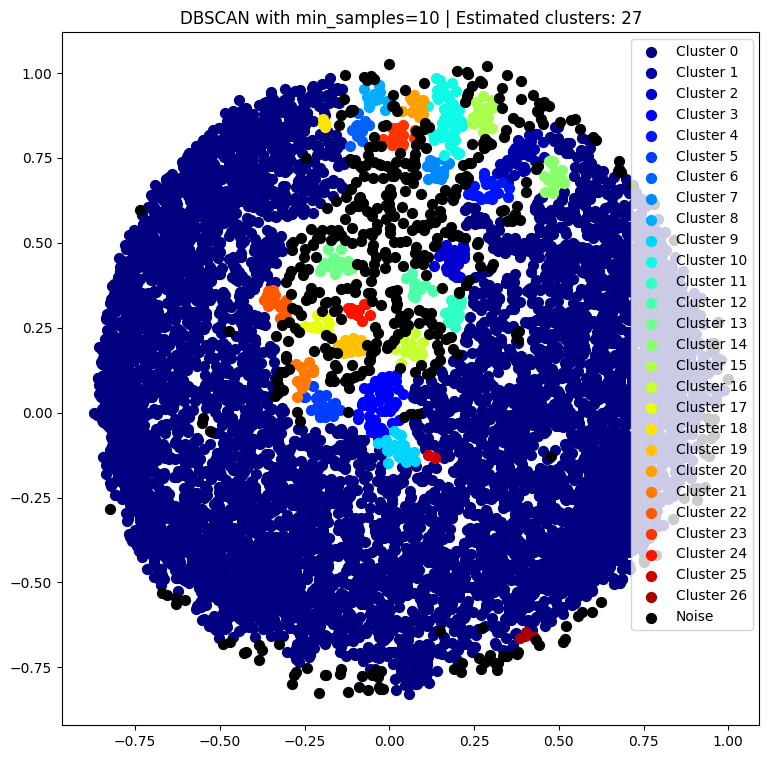

In [9]:
# --- DBSCAN 튜닝 (min_samples=10) ---
db_tuned = DBSCAN(eps=0.0375, min_samples=10).fit(X_principal)
labels1 = db_tuned.labels_


# --- 튜닝 결과 시각화 (오류 수정된 코드) ---
# 고유한 클러스터 레이블을 찾습니다. (-1은 노이즈)
unique_labels = set(labels1)
n_clusters_ = len(unique_labels) - (1 if -1 in labels1 else 0)

# 클러스터 개수만큼 colormap에서 색상을 자동으로 생성합니다.
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

# 각 데이터 포인트에 대한 색상을 지정합니다.
plt.figure(figsize=(9, 9))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # 노이즈는 검은색으로 처리합니다.
        col = 'k'

    class_member_mask = (labels1 == k)

    # 클러스터에 속한 데이터 포인트를 플로팅합니다.
    xy = X_principal[class_member_mask]
    # c=[col] 처럼 리스트로 감싸서 경고 메시지를 피합니다.
    plt.scatter(xy['P1'], xy['P2'], c=[col], s=50, label=f'Cluster {k}' if k != -1 else 'Noise')

plt.title(f'DBSCAN with min_samples=10 | Estimated clusters: {n_clusters_}')
plt.legend()
plt.show()